# Annotation inspection analysis

Load pair-level summary and per-cell UMAP parquet from `run_annotation_inspection_pipeline.py`, then explore cytescore vs confidence and plot lightweight UMAPs without reloading h5ad files.

In [125]:
from pathlib import Path

import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
import pandas as pd

from shared.repo import REPO_ROOT

FIGS_DIR = REPO_ROOT / "writeups/state_vs_cytetype/.figs"
FIGS_DIR.mkdir(exist_ok=True)

In [ ]:
RUN_DIR = REPO_ROOT / "output/annotation_inspection_pipeline" / "20260605_223619"

summary = pd.read_csv(RUN_DIR / "summary.csv")
extremes = pd.read_csv(RUN_DIR / "extremes.csv")

summary["pair_label"] = summary["cell_type"] + summary["cytetype_annotation_leiden_merged"]
summary

In [24]:
print(f"n accessions: {summary["accession"].nunique()}")
print(f"n unique STATE labels: {summary["cell_type"].nunique()}")
print(f"n unique CyteType annotations: {summary["cytetype_annotation_leiden_merged"].nunique()}")

n accessions: 113
n unique STATE labels: 26
n unique CyteType annotations: 868


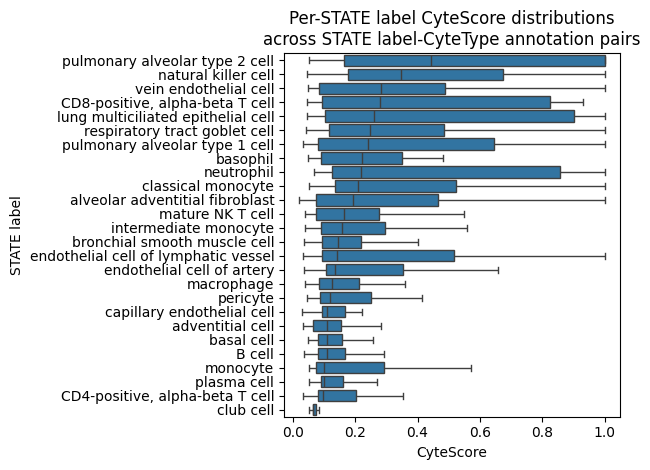

In [ ]:
grp_state = summary.groupby("cell_type")
grp_cyte = summary.groupby("cytetype_annotation_leiden_merged")

# TODO: normalize by n_cells, either by number of occurrences of a given label pair, or by number of occurrances of a STATE label, etc.
cell_type_order = grp_state["cytescore_similarity"].median().sort_values(ascending=False).index

fig, ax = plt.subplots()
sns.boxplot(
    data=summary,
    x="cytescore_similarity",
    y="cell_type",
    order=cell_type_order,
    fliersize=0,
    ax=ax,
)

ax.set_title("Per-STATE label CyteScore distributions\nacross STATE label-CyteType annotation pairs")
ax.set_xlabel("CyteScore")
ax.set_ylabel("STATE label")
plt.tight_layout()
fig.savefig(FIGS_DIR / "cytescore_by_state_boxplot.png", dpi=150, bbox_inches="tight")

In [54]:
x = list(grp_lo["cytescore_similarity"].mean().sort_values().index)

x.index("neutrophil")

0

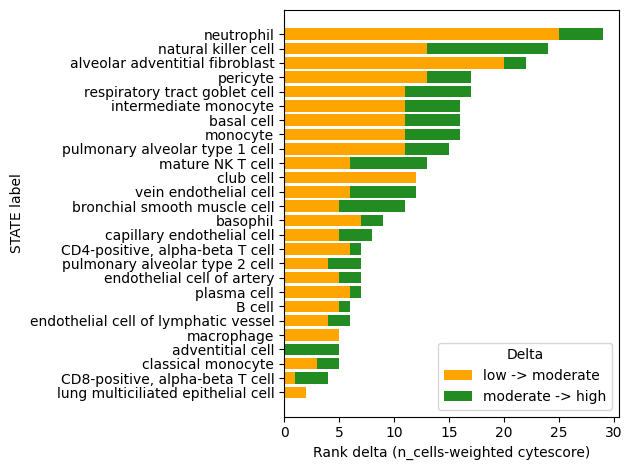

In [126]:
DELTA_COLS = ("low -> moderate", "moderate -> high")
DELTA_COLORS = ("#FFA500", "#228B22")


def mean_rank(confidence: str) -> dict[str, int]:
    mask = summary["cytetype_confidence"] == confidence
    subset = summary.loc[mask]
    weighted_mean = (
        subset.assign(_w=lambda df: df["cytescore_similarity"] * df["n_cells"])
        .groupby("cell_type", observed=True)[["_w", "n_cells"]]
        .sum()
        .assign(mean=lambda df: df["_w"] / df["n_cells"])["mean"]
        .sort_values()
    )
    return dict(zip(weighted_mean.index, range(len(weighted_mean)), strict=False))


lo_rank = mean_rank("Low")
mo_rank = mean_rank("Moderate")
hi_rank = mean_rank("High")

delta = (
    pd.DataFrame(
        {
            "low -> moderate": [abs(lo_rank[ct] - mo_rank[ct]) for ct in lo_rank],
            "moderate -> high": [abs(mo_rank[ct] - hi_rank[ct]) for ct in lo_rank],
        },
        index=lo_rank.keys(),
    )
    .assign(total=lambda df: df.sum(axis=1))
    .sort_values("total", ascending=True)
    .drop(columns="total")
)

fig, ax = plt.subplots()
left = pd.Series(0, index=delta.index)

for col, color in zip(DELTA_COLS, DELTA_COLORS, strict=True):
    ax.barh(delta.index, delta[col], left=left, label=col, color=color)
    left += delta[col]

ax.set_xlabel("Rank delta (n_cells-weighted cytescore)")
ax.set_ylabel("STATE label")
ax.legend(title="Delta")
plt.tight_layout()
fig.savefig(FIGS_DIR / "cytescore_rank_delta_by_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

In [122]:
x = summary[summary["cell_type"] == "basophil"]
x["weighted_cytescore"] = x["cytescore_similarity"] * x["n_cells"]
x

/var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/ipykernel_64742/826919280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["weighted_cytescore"] = x["cytescore_similarity"] * x["n_cells"]


,accession,cell_type,cytetype_annotation_leiden_merged,leiden_merged,cytetype_confidence,cytescore_similarity,n_cells,report_url,pair_label,weighted_cytescore
274,SRX14098306,basophil,Alveolar macrophage with plasma cell contamina...,5,Moderate,0.1165,1,https://cytetype.nygen.io/report/7ecc341a-fe59...,basophilAlveolar macrophage with plasma cell c...,0.1165
275,SRX14098306,basophil,Alveolar type 1 (AT1) cell,6,High,0.0678,2,https://cytetype.nygen.io/report/7ecc341a-fe59...,basophilAlveolar type 1 (AT1) cell,0.1356
276,SRX14098306,basophil,CD8+ cytotoxic T cell,0,Moderate,0.0734,4,https://cytetype.nygen.io/report/7ecc341a-fe59...,basophilCD8+ cytotoxic T cell,0.2936
277,SRX14098306,basophil,Endothelial cell,4,Low,0.1517,1,https://cytetype.nygen.io/report/7ecc341a-fe59...,basophilEndothelial cell,0.1517
278,SRX14098306,basophil,Tryptase-high mucosal mast cells,18,High,0.2709,76,https://cytetype.nygen.io/report/7ecc341a-fe59...,basophilTryptase-high mucosal mast cells,20.5884
...,...,...,...,...,...,...,...,...,...,...
7931,SRX9276294,basophil,Mast cells (MCT),4,High,0.2709,89,https://cytetype.nygen.io/report/0d454832-6f15...,basophilMast cells (MCT),24.1101
8133,SRX9276319,basophil,Activated MAIT cell,1,Moderate,0.1130,1,https://cytetype.nygen.io/report/bf5c447a-5fcb...,basophilActivated MAIT cell,0.1130
8134,SRX9276319,basophil,MCTC mast cells,4,High,0.2709,197,https://cytetype.nygen.io/report/bf5c447a-5fcb...,basophilMCTC mast cells,53.3673
8135,SRX9276319,basophil,Monocyte-derived macrophage,0,Moderate,0.1562,1,https://cytetype.nygen.io/report/bf5c447a-5fcb...,basophilMonocyte-derived macrophage,0.1562


## Pair-level groupbys

In [39]:
summary.groupby(["cytetype_confidence", "accession"], observed=True)["cytescore_similarity"].mean().unstack()

accession,SRX10048389,SRX10100448,SRX11438989,SRX12285822,SRX14098306,SRX14767851,SRX14767852,SRX14767853,SRX14767854,SRX14767855,...,SRX9276294,SRX9276295,SRX9276309,SRX9276315,SRX9276316,SRX9276318,SRX9276319,SRX9276320,SRX9276323,SRX9276336
cytetype_confidence,,,,,,,,,,,,,,,,,,,,,
High,0.184304,0.249309,0.203407,NaN,0.185464,0.64252,0.353077,0.440006,0.525300,0.314289,...,0.259390,0.202091,0.182575,0.243037,0.171750,0.377245,0.188390,0.174425,0.211462,0.236220
Low,0.176096,NaN,0.137729,0.174215,0.181058,0.42110,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.182586,NaN,NaN,NaN,NaN,NaN
Moderate,0.199179,0.223200,0.235058,0.153520,0.189620,0.35395,0.318575,NaN,0.471256,0.333940,...,0.186704,0.242657,0.213809,0.202644,0.228669,NaN,0.144242,0.156621,0.242048,0.181029


In [6]:
summary.groupby("cytetype_confidence", observed=True)["cytescore_similarity"].describe()

,count,mean,std,min,25%,50%,75%,max
cytetype_confidence,,,,,,,,
High,3593.0,0.231411,0.236558,0.0312,0.0853,0.1266,0.278000,1.0
Low,561.0,0.192929,0.188113,0.0361,0.0897,0.1235,0.201100,1.0
Moderate,4226.0,0.220365,0.221385,0.0211,0.0850,0.1250,0.258275,1.0


## Extremes table

In [ ]:
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(extremes)

## Lightweight UMAP plots

In [ ]:
import json
import os

from scanpy.plotting._utils import set_colors_for_categorical_obs

LOCAL_H5AD_FOLDER = REPO_ROOT / "data/cytetype_annotated"
H5AD_FILE_INDEX = 0
available_files = sorted(os.listdir(LOCAL_H5AD_FOLDER))
h5ad_path = LOCAL_H5AD_FOLDER / available_files[H5AD_FILE_INDEX]
ACCESSION = available_files[H5AD_FILE_INDEX].split("_")[0]

adata = sc.read(h5ad_path)

cyteonto_df = pd.read_csv(
    REPO_ROOT / "output/cyteonto_pipeline/deduplicated_tables/deduplicated.csv"
)
cyteonto_df = cyteonto_df[cyteonto_df["accession"] == ACCESSION]
adata.obs["pair_label"] = (
    adata.obs["cell_type"].astype(str) + adata.obs["cytetype_annotation_leiden_merged"].astype(str)
)
cyteonto_df = cyteonto_df.set_index("pair_label")
adata.obs = adata.obs.set_index("pair_label")
adata.obs = adata.obs.join(cyteonto_df[["cytescore_similarity"]], how="left")
adata.obs = adata.obs.reset_index()

cluster_key = "leiden_merged"
payload = adata.uns["cytetype_results"]["result"]
cytetype_result = json.loads(payload) if isinstance(payload, str) else payload
confidence_by_cluster = {
    str(cluster_id): entry["latest"]["review"]["confidence"]
    for cluster_id, entry in cytetype_result["raw_annotations"].items()
}
adata.obs["cytetype_confidence"] = pd.Categorical(
    adata.obs[cluster_key].map(confidence_by_cluster),
    categories=["High", "Moderate", "Low"],
    ordered=True,
)

confidence_palette = {"Low": "#d73027", "Moderate": "#fee08b", "High": "#1a9850"}
set_colors_for_categorical_obs(adata, "cytetype_confidence", confidence_palette)

fig = sc.pl.umap(
    adata,
    color=[
        "cell_type",
        "cytetype_annotation_leiden_merged",
        "cytescore_similarity",
        "cytetype_confidence",
    ],
    title=[
        f"{ACCESSION}: STATE labels",
        f"{ACCESSION}: CyteType annotations",
        f"{ACCESSION}: CyteOnto cytescore similarity",
        f"{ACCESSION}: CyteType cluster confidence",
    ],
    ncols=2,
    legend_loc="right margin",
    size=30,
    wspace=0.4,
    return_fig=True,
)
fig.savefig(FIGS_DIR / "umap_example_accession.png", dpi=150, bbox_inches="tight")